# What is the True Normal Human Body Temperature? 

#### Background

The mean normal body temperature was held to be 37$^{\circ}$C or 98.6$^{\circ}$F for more than 120 years since it was first conceptualized and reported by Carl Wunderlich in a famous 1868 book. But, is this value statistically correct?

<h3>Exercises</h3>

<p>In this exercise, you will analyze a dataset of human body temperatures and employ the concepts of hypothesis testing, confidence intervals, and statistical significance.</p>

<p>Answer the following questions <b>in this notebook below and submit to your Github account</b>.</p> 

<ol>
<li>  Is the distribution of body temperatures normal? 
    <ul>
    <li> Although this is not a requirement for the Central Limit Theorem to hold (read the introduction on Wikipedia's page about the CLT carefully: https://en.wikipedia.org/wiki/Central_limit_theorem), it gives us some peace of mind that the population may also be normally distributed if we assume that this sample is representative of the population.
    <li> Think about the way you're going to check for the normality of the distribution. Graphical methods are usually used first, but there are also other ways: https://en.wikipedia.org/wiki/Normality_test
    </ul>
<li>  Is the sample size large? Are the observations independent?
    <ul>
    <li> Remember that this is a condition for the Central Limit Theorem, and hence the statistical tests we are using, to apply.
    </ul>
<li>  Is the true population mean really 98.6 degrees F?
    <ul>
    <li> First, try a bootstrap hypothesis test.
    <li> Now, let's try frequentist statistical testing. Would you use a one-sample or two-sample test? Why?
    <li> In this situation, is it appropriate to use the $t$ or $z$ statistic? 
    <li> Now try using the other test. How is the result be different? Why?
    </ul>
<li>  Draw a small sample of size 10 from the data and repeat both frequentist tests. 
    <ul>
    <li> Which one is the correct one to use? 
    <li> What do you notice? What does this tell you about the difference in application of the $t$ and $z$ statistic?
    </ul>
<li>  At what temperature should we consider someone's temperature to be "abnormal"?
    <ul>
    <li> As in the previous example, try calculating everything using the boostrap approach, as well as the frequentist approach.
    <li> Start by computing the margin of error and confidence interval. When calculating the confidence interval, keep in mind that you should use the appropriate formula for one draw, and not N draws.
    </ul>
<li>  Is there a significant difference between males and females in normal temperature?
    <ul>
    <li> What testing approach did you use and why?
    <li> Write a story with your conclusion in the context of the original problem.
    </ul>
</ol>

You can include written notes in notebook cells using Markdown: 
   - In the control panel at the top, choose Cell > Cell Type > Markdown
   - Markdown syntax: http://nestacms.com/docs/creating-content/markdown-cheat-sheet

#### Resources

+ Information and data sources: http://www.amstat.org/publications/jse/datasets/normtemp.txt, http://www.amstat.org/publications/jse/jse_data_archive.htm
+ Markdown syntax: http://nestacms.com/docs/creating-content/markdown-cheat-sheet

****

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('data/human_body_temperature.csv')
df.head()

,temperature,gender,heart_rate
0,99.3,F,68.0
1,98.4,F,81.0
2,97.8,M,73.0
3,99.2,F,66.0
4,98.0,F,73.0


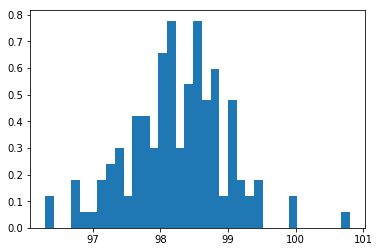

[ 0.3414136  -0.11302013  0.04165042  0.06924495 -0.52158035 -0.25845804
  0.47903413]


96.04968129511394

In [45]:
# Your work here.
#pull temperature data from dataframe
temp=df['temperature']
#plot histogram of data to check if normal
plt.hist(temp,bins=35,normed=True)
plt.show()
#get the mean and standard deviation of data
std=temp.std()
mean=temp.mean()
#create array comparing values to expected data if data is normal
b=np.array([temp.min()-(mean-std*3),np.percentile(temp,2.275)-(mean-std*2),np.percentile(temp,15.865)-(mean-std),np.percentile(temp,50)-mean,np.percentile(temp,65.865)-(mean+std),np.percentile(temp,97.725)-(mean+std*2),temp.max()-(mean+std*3)])
#check the deviation from expected values
print(b/std)


1.ALthough close to normal the data is most likely not normal, 
2. The data is large n=130 and independnt, each person's measured valus shouldn't affect other people's values.

In [86]:
def draw_bs_reps(data,func,size):
    bs_return=np.empty(size)
    for i in range(size):
        bs_return[i]=func(np.random.choice(data,size=len(data)))
    return bs_return

In [88]:
shifted_temp=temp-temp.mean()+98.6
bs=draw_bs_reps(shifted_temp,np.mean,10)
np.sum(bs<=np.mean(temp))/10

0.0

In [101]:
females=df.temperature[df.gender=='F'].reset_index()['temperature']
males=df.temperature[df.gender=='M'].reset_index()['temperature']
f_shift=females-females.mean()+temp.mean()
m_shift=males-males.mean()+temp.mean()
f_bs=draw_bs_reps(f_shift,np.mean,10000)
m_bs=draw_bs_reps(f_shift,np.mean,10000)
gender_bs=f_bs-m_bs
np.sum(gender_bs>=np.mean(females-males))/10000

0.0129

In [118]:
q1=np.percentile(temp,25)
q3=np.percentile(temp,75)
print(q1-1.5*(q3-q1))
print(q3+1.5*(q3-q1))
temp.max()
temp.min()

96.44999999999999
100.05000000000001


96.3